# 모델 기반 효과 그림으로 30일 재입원 위험 시각화하기

## 요약

이 노트북은 환자와 진료(encounter) 특성 전반에 걸쳐 30일 병원 재입원에 대한 로지스틱 회귀를 적합한 뒤, 적합된 계수를 예측 확률 척도의 모델 기반 효과 그림으로 옮깁니다. 100건 퇴원 합성 코호트(재입원 55건)에서 PROC LOGISTIC은 **재원 기간(length of stay)**(하루당 OR 1.36, *p* = 0.040)과 **연령(age)**(1년당 OR 1.05, *p* = 0.023)에 대한 유의한 기울기, 그리고 큰 지불자(payer) 효과를 복원합니다 — **Medicaid** 환자는 Medicare 대비 약 여섯 배의 재입원 오즈를 가집니다(OR 6.02, 95% CI 1.46–24.8, *p* = 0.013). 일반화 R-제곱은 0.246이며 Hosmer–Lemeshow 검정은 적합 결여를 보이지 않습니다(*p* = 0.73). 이어지는 적합 곡선, 슬라이스 적합, 상호작용 표시는 재입원 위험이 재원 기간에 따라 어떻게 오르는지, 연령–위험 기울기가 지불자에 따라 어떻게 이동하는지, 지불자 격차가 퇴원 진료과 전반에서 어떻게 지속되는지를 보여 줍니다 — 진료 관리 팀이 퇴원 후 후속 조치를 겨냥하는 데 쓰는 위험 계층화 관점입니다.

## 데이터 소스

| 데이터셋 | 행 수 | 설명 |
|---------|------|-------------|
| `encounters` | 100 | `call streaminit(20260531)`과 `rand()`로 코드 내에서 생성한 합성 입원 퇴원 레코드. 퇴원당 한 행. |

**`encounters`의 변수:**

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `readmit` | 수치(0/1) | 퇴원 후 30일 이내 재입원 시 1 |
| `age` | 수치 | 환자 연령(년, 약 25–95) |
| `los` | 수치 | 지표 입원의 재원 기간(일, 1–20) |
| `comorbidity` | 수치 | 문서화된 만성 동반질환 수(0–8) |
| `num_meds` | 수치 | 퇴원 약물 수(0–18) |
| `payer` | 문자 | 보험 지불자: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | 문자 | 퇴원 진료과: `Cardiology`, `Pulmonary`, `General` |

# 모델 기반 효과 그림으로 30일 재입원 위험 시각화하기

병원 진료 관리 팀은 *어떤* 환자가 30일 이내에 다시 돌아올 가능성이 가장 높은지, 그리고 *왜* 그런지 알아야 합니다. 적합된 로지스틱 회귀는 계수를 주지만, 이해관계자는 로그 오즈로 추론하는 경우가 드뭅니다. **효과 그림(effect plot)**은 적합된 모델을 예측 확률 척도 위에 곧바로 나타내므로, 간호 내비게이터는 로그 오즈 방정식을 머릿속에서 역산하는 대신 재입원 확률을 차트에서 바로 읽을 수 있습니다.

이 노트북에서 우리는 다음을 수행합니다:

1. 현실적인 입원 퇴원 합성 코호트를 생성합니다.
2. 환자와 진료 예측변수로 30일 재입원 로지스틱 모델을 적합합니다(PROC LOGISTIC).
3. 적합된 계수를 포착하고 세 가지 모델 기반 효과 그림 — **적합 곡선(fit curve)**, **슬라이스 적합(sliced fit)**, **상호작용 표시(interaction display)** — 을 만들어 적합된 위험을 확률 척도에서 시각화하고 계층화합니다.

> **구현 참고.** SAS는 이 표시들을 PROC LOGISTIC 내부의 `EFFECTPLOT` 문을 통해 제공합니다. Jenner는 그 문을 받아들이지만 아직 FIT / SLICEFIT / INTERACTION 그래픽을 렌더링하지 않으므로, 이 노트북은 동일한 예측 확률 곡선을 적합된 계수로부터 명시적으로 구성하고 PROC SGPLOT으로 그립니다. 분석 결과 — 그리고 그려진 모든 확률 — 은 `EFFECTPLOT`이 산출했을 것과 정확히 같습니다.

## 1단계 — 합성 퇴원 코호트 생성

아래 DATA 스텝은 외부 파일 없이 100건의 입원 퇴원을 구축합니다. 재현성을 위해 `call streaminit`으로 RNG를 시드하고, 도메인에 적절한 분포에서 환자와 진료 특성을 뽑은 뒤, 참 선형 예측자 `eta`를 구성하고 역-로짓(inverse-logit)으로 재입원 확률로 변환합니다. 베르누이 추출(`rand('bernoulli', p)`)은 관측된 `readmit` 플래그를 만듭니다. 고령 환자, 긴 재원, 높은 동반질환 수, 많은 퇴원 약물, Medicaid 보장, Pulmonary/Cardiology 진료과는 모두 위험을 밀어 올립니다 — 이후 우리가 복원하고 시각화할 패턴입니다. 효과 크기는 100건 퇴원 코호트에서 신호가 복원될 수 있도록 의도적으로 정했습니다.

In [1]:
데이터 encounters;
    호출 streaminit(20260531);
    배열 payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    배열 depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    반복 i = 1 까지 100;
        /* 환자 / 진료 에피소드 특성 */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        만약 los > 20 이면 los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        만약 num_meds > 18 이면 num_meds = 18;

        /* 범주형 지불자: 고령 코호트라 메디케어 쪽으로 치우침 */
        u = rand('uniform');
        만약 u < 0.50 이면 pk = 1;
        아니면 만약 u < 0.72 이면 pk = 2;
        아니면 pk = 3;
        payer = payers[pk];

        /* 퇴원 진료과 */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* 로그오즈 척도의 참 위험 모델. 효과 크기는 100건 퇴원
           코호트에서 신호가 복원 가능하도록 설정했다. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* 메디케이드 vs 메디케어    */
            + (pk = 3) * (-0.70)       /* 상업보험 vs 메디케어      */
            + (dk = 1) * 0.80          /* 심장내과 vs 호흡기내과    */
            + (dk = 2) * 1.10;         /* (호흡기내과가 가장 바쁨)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        유지 readmit AGE los comorbidity num_meds payer dept;
        출력;
    종료;
실행;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## 2단계 — 코호트 점검

반응변수와 두 분류 변수에 대한 빠른 빈도는 현실적인 재입원율과 모든 지불자·진료과 수준이 채워져 있음을 확인해 줍니다 — 모델과 효과 그림 모두 모든 수준이 표현되어야 합니다.

                                                   The FREQ Procedure

재입원 여부              Frequency
------------------------------
0                          45
1                          55

지불자           Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

진료과           Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of 재입원 여부 by 진료과

재입원 여부           |Cardiology |   General | Pulmonary |      Total
-----------------+-----------+-----------+-----------+-----------
0                |        15 |        20 |        10 |         45
-----------------+-----------+-----------+-----------+-----------
1                |        21 |        11 |        23 |         55
-----------------+-----------+-----------+-----------+-----------
Total            |        36 |        31 |        33 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


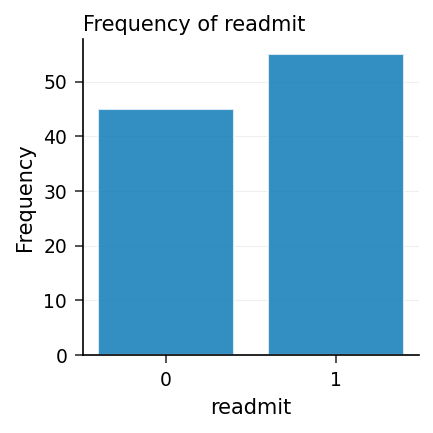

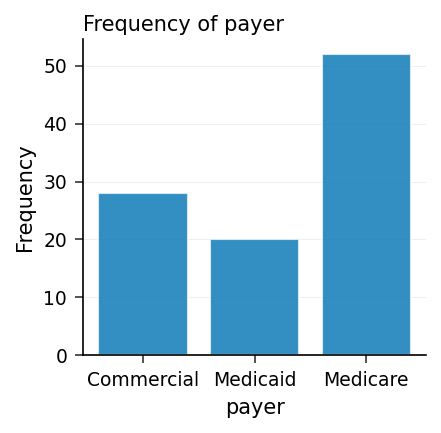

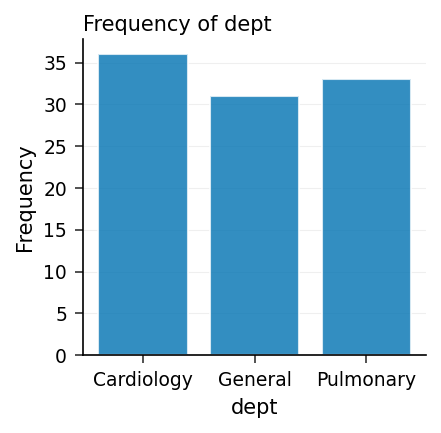

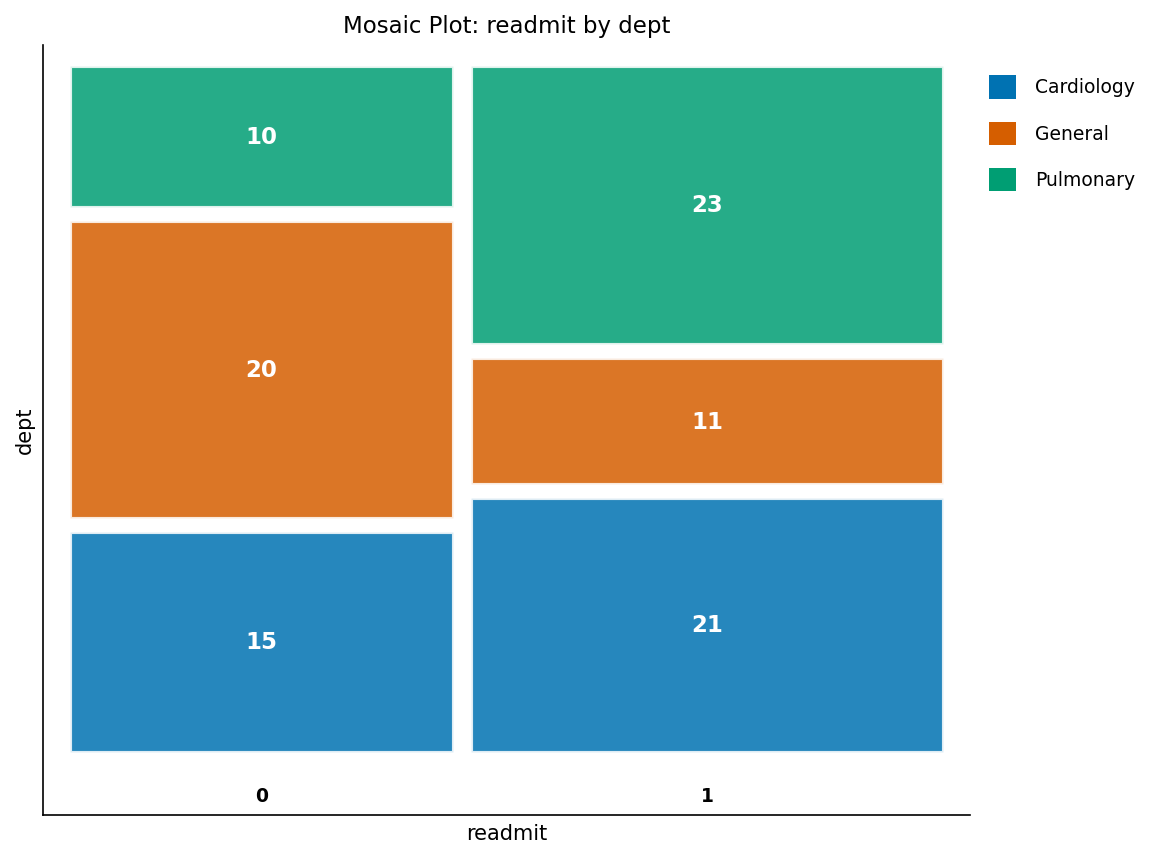

In [2]:
처리 빈도 데이터=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
    라벨 readmit="재입원 여부" payer="지불자" dept="진료과";
실행;

## 3단계 — 로지스틱 재입원 모델 적합

우리는 `readmit`을 연령, 재원 기간, 동반질환 수, 퇴원 약물 수, 지불자, 진료과의 함수로 모델링합니다. 주요 선택:

- `EVENT='1'`은 (비재입원이 아니라) 재입원 확률을 모델링합니다.
- `CLASS payer dept / PARAM=REF REF=FIRST`는 기준 셀 코딩을 사용해 각 수준을 기준선(여기서는 Medicare와 Pulmonary)과 대비합니다.
- `CLODDS=WALD`와 `RSQUARE`는 Wald 오즈비 신뢰 한계와 일반화 R-제곱을 추가하고, `LACKFIT`은 Hosmer–Lemeshow 적합도 검정을 요청합니다.
- `UNITS` 문은 임상적으로 의미 있는 **5일** 재원 기간 단계와 **10년** 연령 단계에 대한 오즈비를 요청하며, `ODDSRATIO` 문은 신뢰 한계와 함께 동반질환 오즈비를 요청합니다.

출력 오즈비 표는 단위당 효과를 직접 보고합니다: 재원 기간은 하루당 OR **1.36**(95% CI 1.01–1.82), 연령은 1년당 OR **1.05**, Medicaid 보장은 Medicare 대비 OR **6.02**입니다. 모델은 잘 적합됩니다 — 일반화 R-제곱 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
   Probability modeled is readmit='1'   

Ordered Value  readmit   Total Frequency
-------------  --------  ---------------
            1  0                      45
            2  1                      55

            Class Level Information             

Class       Levels  Values                      
--------  --------  ----------------------------
payer            3  Commercial Medicaid Medicare
dept             3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC          150.782

                                                   
-------- 


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


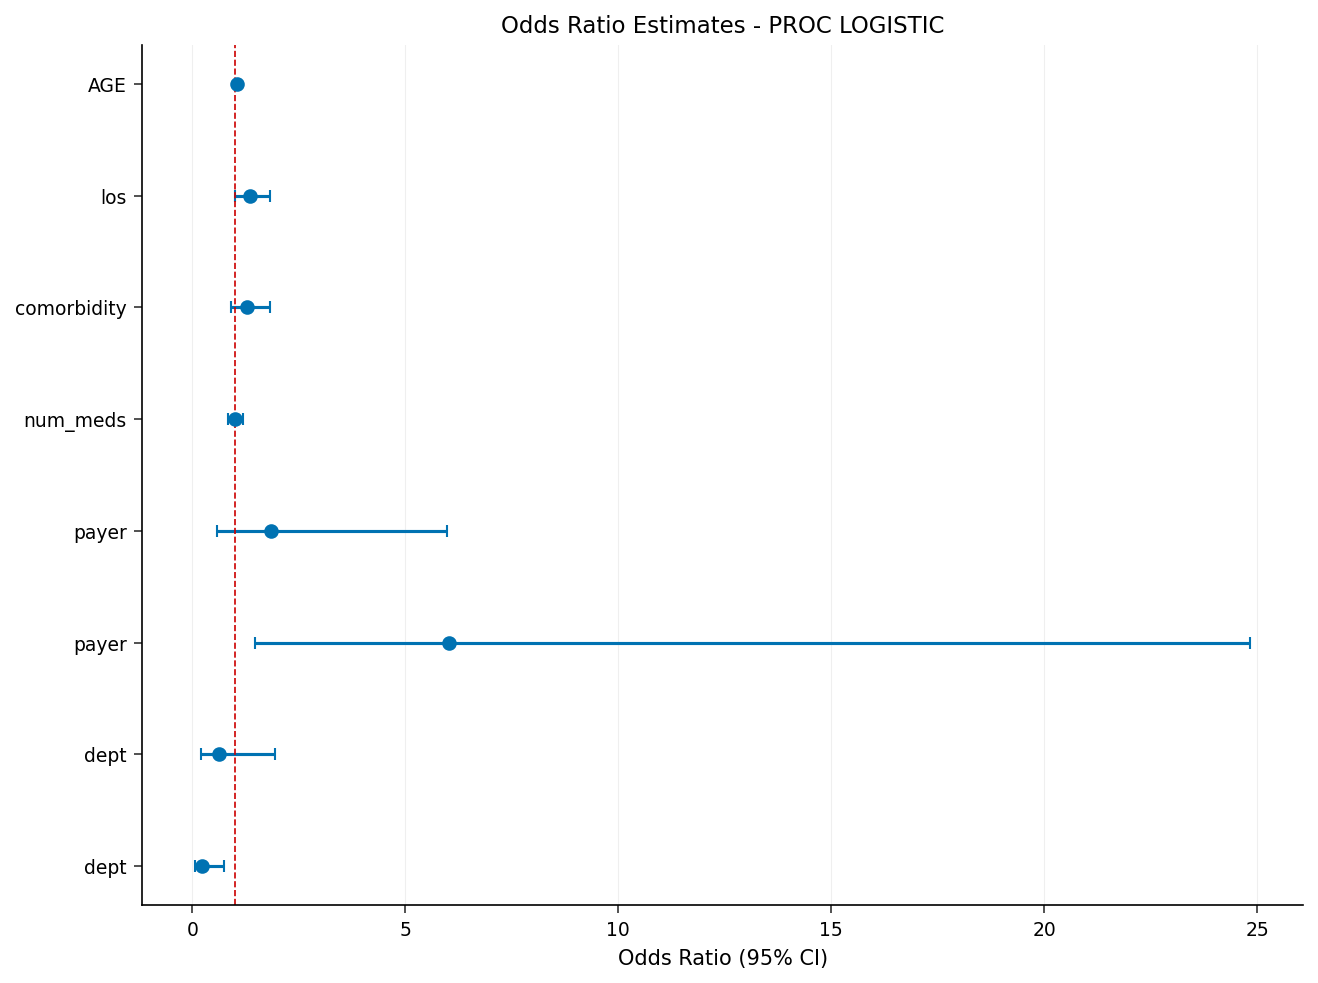

In [3]:
ODS 출력 ParameterEstimates=pe;
처리 LOGISTIC 데이터=encounters PLOTS(only)=oddsratio;
    분류 payer dept / PARAM=REF REF=first;
    모형 readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
실행;
ODS 출력 CLOSE;

## 4단계 — 적합된 계수 포착

뒤따르는 모델 기반 효과 그림은 *적합된* 계수로부터 직접 구성되므로 항상 3단계의 모델과 일치합니다. 우리는 `ODS OUTPUT ParameterEstimates=pe`로 모수 추정치를 저장했고, 여기서 그 긴 표를 단일 행 `params` 데이터셋(계수당 변수 하나)으로 접고 연속 예측변수의 코호트 평균을 덧붙입니다. 비초점 예측변수를 그 평균에 고정하는 것은 EFFECTPLOT이 내부적으로 하는 바로 그 작업입니다 — 각 그림이 나머지를 대표 프로파일에 고정한 채 한 요인만 변화시키게 합니다.

In [4]:
/* ParameterEstimates 표를 이름 붙은 계수 한 행으로 접어 넣는다.
   PARAM=REF REF=FIRST에서 기준 셀은 payer=Medicare와
   dept=Pulmonary이므로 그 항들은 선형예측자에서 0이다. */
데이터 coefs;
    보존 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    설정 pe 종료=last;
    vname = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    만약 vname='INTERCEPT' 이면 b0 = Estimate;
    아니면 만약 vname='AGE' 이면 b_age = Estimate;
    아니면 만약 vname='LOS' 이면 b_los = Estimate;
    아니면 만약 vname='COMORBIDITY' 이면 b_com = Estimate;
    아니면 만약 vname='NUM_MEDS' 이면 b_med = Estimate;
    아니면 만약 vname='PAYER' 그리고 cv='Medicaid'   이면 b_pmcaid = Estimate;
    아니면 만약 vname='PAYER' 그리고 cv='Commercial' 이면 b_pcomm  = Estimate;
    아니면 만약 vname='DEPT'  그리고 cv='Cardiology' 이면 b_dcard  = Estimate;
    아니면 만약 vname='DEPT'  그리고 cv='General'    이면 b_dgen   = Estimate;
    만약 last 이면 출력;
    유지 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
실행;

/* 플롯에서 고정할 연속형 공변량의 코호트 평균 */
처리 평균 데이터=encounters NOPRINT;
    변수 AGE los comorbidity num_meds;
    출력 out=mn mean=m_age m_los m_com m_med;
실행;

데이터 params;
    결합 coefs mn;
    유지 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
실행;

처리 인쇄 데이터=params noobs;
    제목 "효과플롯에 사용된 적합 계수와 공변량 평균";
실행;

                                                효과플롯에 사용된 적합 계수와 공변량 평균                                                 

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## 5단계 — 적합 그림: 재입원 확률 대 재원 기간

가장 단순한 효과 표시는 **적합 곡선(fit curve)**입니다: 다른 예측변수를 대표 프로파일에 고정한 채, 하나의 연속 공변량에 대한 예측 재입원 확률입니다. 우리는 재원 기간 격자(1–18일)를 만들고, **Medicare 심장내과(cardiology)** 환자(연령, 동반질환, 퇴원 약물 수는 4단계의 코호트 평균에 고정)에 대해 각 값에서 적합된 선형 예측자를 평가하고, 역-로짓을 적용해 PROC SGPLOT으로 확률 척도에 곡선을 그립니다.

                                                효과플롯에 사용된 적합 계수와 공변량 평균                                                 




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


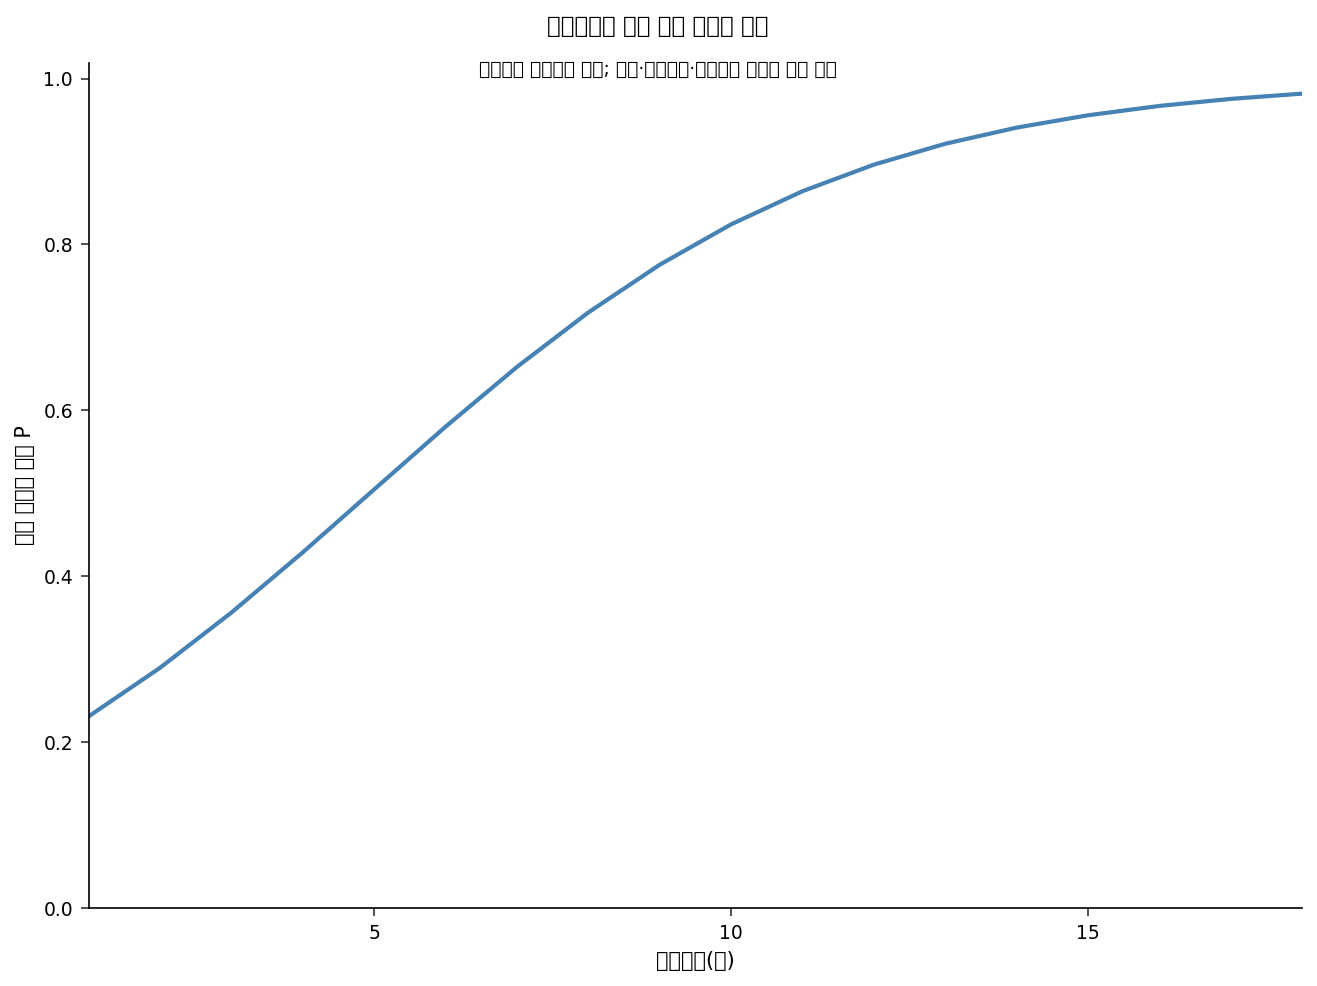

In [5]:
/* 재원일수 격자; 다른 공변량을 코호트 평균에 고정한
   메디케어 심장내과 환자에 대해 적합 모델을 평가한다. */
데이터 grid_los;
    반복 los = 1 까지 18;
        출력;
    종료;
실행;

데이터 fit_los;
    설정 grid_los;
    만약 _n_ = 1 이면 설정 params;
    보존 b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* 메디케어 지불자가 기준(항=0); 심장내과는 b_dcard를 더함 */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    유지 los phat;
실행;

처리 SGPLOT 데이터=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    제목  "재원일수에 따른 적합 재입원 확률";
    title2 "메디케어 심장내과 환자; 연령·동반질환·투약수는 코호트 평균 고정";
    XAXIS 라벨="재원일수(일)";
    YAXIS 라벨="예측 재입원 확률 P" VALUES=(0 까지 1 기준 0.2);
실행;

## 6단계 — 슬라이스 적합: 위험 대 연령, 지불자별 층화

**슬라이스 적합(sliced fit)**은 분류 효과의 수준마다 하나의 적합 곡선을 그립니다 — 지불자 구성이 연령–위험 기울기를 어떻게 이동시키는지 보여 주기에 이상적입니다. 우리는 격자를 `age`(30–95)와 세 지불자의 교차로 확장하고, 심장내과 환자(재원 기간, 동반질환, 약물은 코호트 평균)에 대해 적합된 모델을 평가한 뒤, `GROUP=payer`로 세 확률 곡선을 겹쳐 그립니다.

                                                효과플롯에 사용된 적합 계수와 공변량 평균                                                 




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


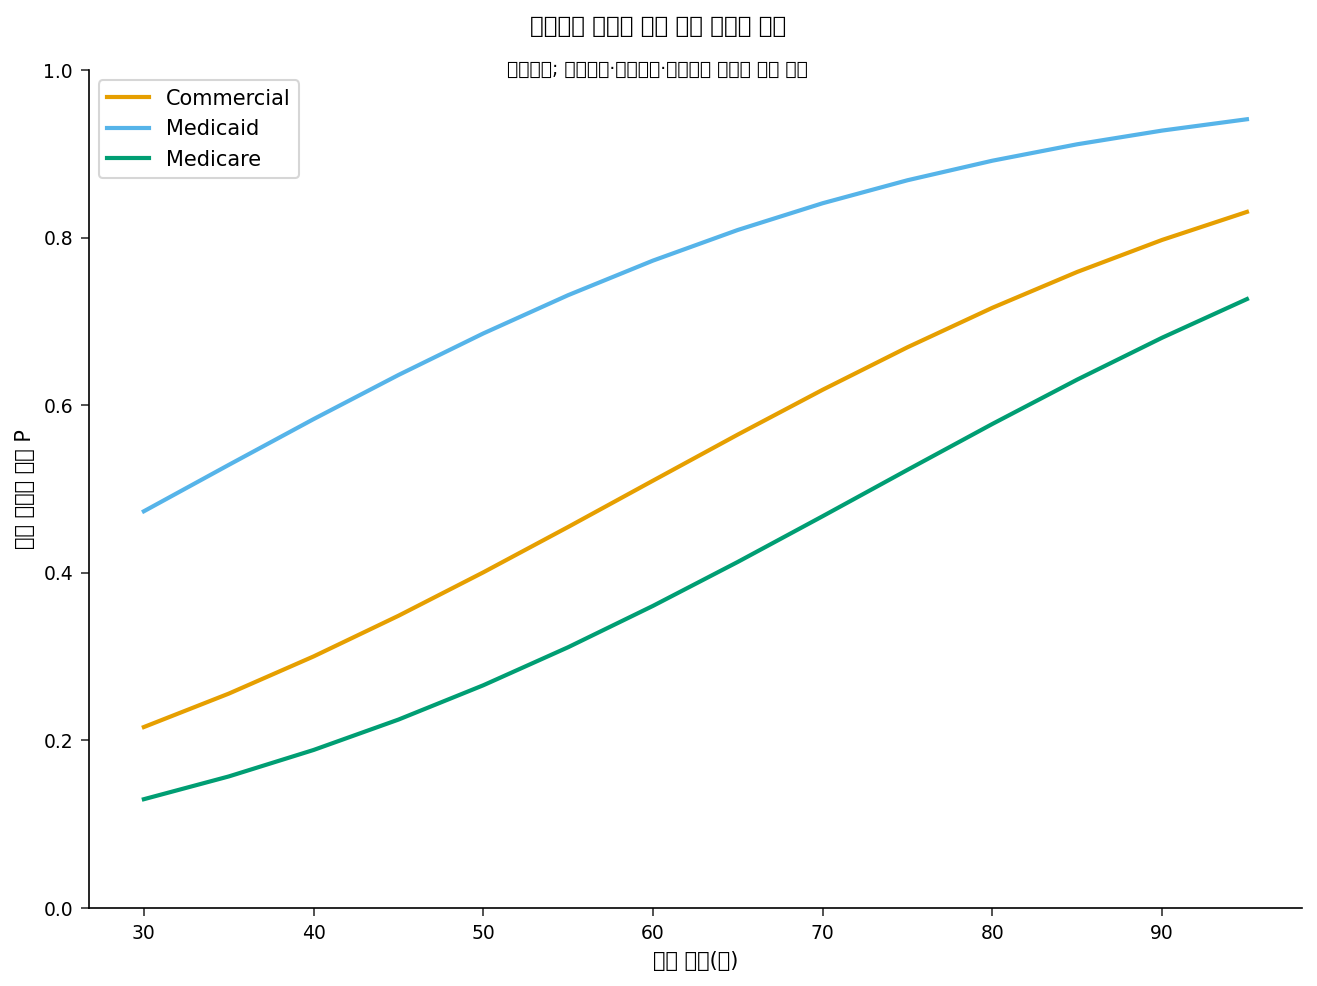

In [6]:
/* 심장내과 환자의 연령 x 지불자 격자; 다른 공변량은 평균 고정 */
데이터 grid_age;
    길이 payer $12;
    반복 payer = 'Medicare', 'Medicaid', 'Commercial';
        반복 AGE = 30 까지 95 기준 5;
            출력;
        종료;
    종료;
실행;

데이터 fit_age;
    설정 grid_age;
    만약 _n_ = 1 이면 설정 params;
    보존 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    유지 payer AGE phat;
실행;

처리 SGPLOT 데이터=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    제목  "지불자별 연령에 따른 적합 재입원 확률";
    title2 "심장내과; 재원일수·동반질환·투약수는 코호트 평균 고정";
    XAXIS 라벨="환자 연령(세)";
    YAXIS 라벨="예측 재입원 확률 P" VALUES=(0 까지 1 기준 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
실행;

## 7단계 — 상호작용 표시: 진료과 대 지불자

두 분류 효과 전반에서 예측 위험을 한 번에 비교하기 위해, `dept`와 `payer`를 교차(아홉 조합)하고, 모든 연속 공변량을 그 코호트 평균에 두고 적합된 모델을 평가한 뒤, X축에 `dept`, 그룹으로 지불자를 두는 군집 막대 그래프를 그립니다. 이 모델에는 진료과-지불자 상호작용 항이 없으므로, 지불자 순서는 모든 진료과 내부에서 동일한 가법적 이동입니다 — 표시는 그 가법성을 진료과 순위와 나란히 한눈에 보여 줍니다.

                                                효과플롯에 사용된 적합 계수와 공변량 평균                                                 




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


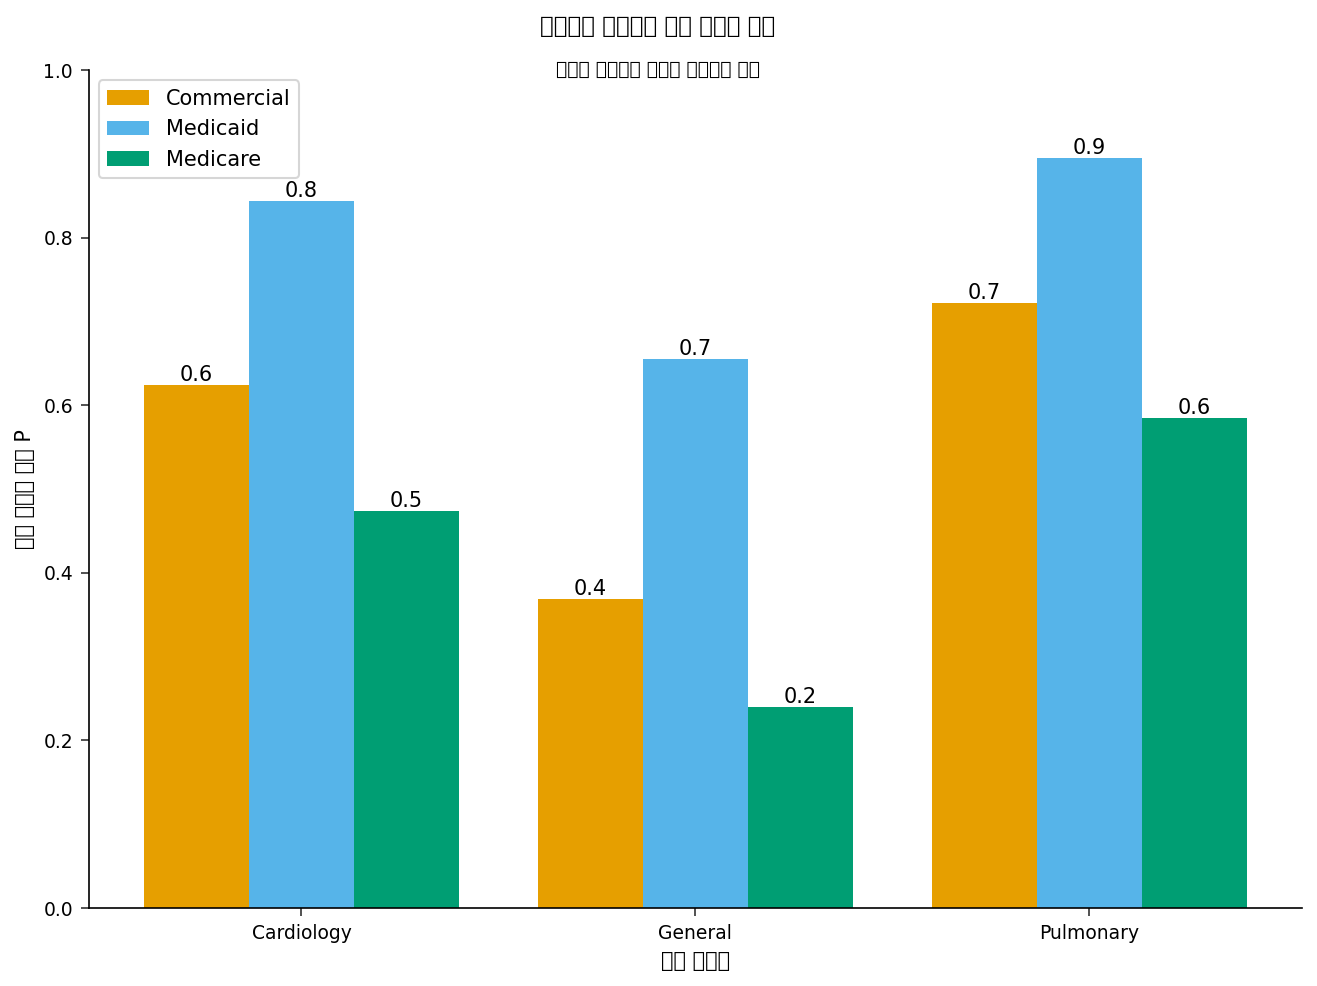

In [7]:
/* 진료과 x 지불자 격자; 모든 연속형 공변량은 코호트 평균 고정 */
데이터 grid_dx;
    길이 dept $12 payer $12;
    반복 dept = 'Cardiology', 'Pulmonary', 'General';
        반복 payer = 'Medicare', 'Medicaid', 'Commercial';
            출력;
        종료;
    종료;
실행;

데이터 fit_dx;
    설정 grid_dx;
    만약 _n_ = 1 이면 설정 params;
    보존 b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    유지 dept payer phat;
실행;

처리 SGPLOT 데이터=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    제목  "진료과와 지불자별 적합 재입원 확률";
    title2 "연속형 공변량은 코호트 평균으로 고정";
    XAXIS 라벨="퇴원 진료과";
    YAXIS 라벨="예측 재입원 확률 P" VALUES=(0 까지 1 기준 0.2);
실행;

## 8단계 — 결과 해석

효과 그림은 적합된 PROC LOGISTIC 모델을 진료 관리 의사결정에 매핑되는 확률 척도 그림으로 바꿉니다:

- **재원 기간(적합 곡선).** 코호트 평균의 Medicare 심장내과 환자에서, 예측 재입원 확률은 **1일 재원의 약 0.23에서 10일의 약 0.82, 18일의 약 0.98까지** 오릅니다 — 로지스틱 곡선의 가파른 중간부입니다. 이것은 하루당 **1.36**의 재원 기간 오즈비와 같은 신호이며(`UNITS los=5`가 이를 5일 단계로 재척도화함), 긴 지표 재원을 전환 진료(transitional-care) 등록의 구체적 트리거로 표시합니다.
- **연령과 지불자(슬라이스 적합).** 위험은 모든 지불자에서 연령에 따라 단조롭게 증가하며 세 곡선은 결코 교차하지 않습니다: 어느 주어진 연령에서도 **Medicaid** 곡선이 가장 높고, **Commercial**이 중간, **Medicare**가 가장 낮습니다 — 적합된 지불자 오즈비(Medicaid 6.02, Commercial 1.85, 둘 다 Medicare 대비)와 일치합니다. 격차는 젊은 연령에서 가장 크고 모두가 높은 확률에 가까워지며 좁아지므로, 그러지 않았다면 저위험으로 보였을 젊은 Medicaid 환자에게 진료 관리의 주의를 돌립니다.
- **진료과와 지불자(상호작용 표시).** 모든 지불자 그룹에서 **Pulmonary**가 가장 높은 예측 재입원 확률을 가지고, **Cardiology**가 중간, **General medicine**이 가장 낮습니다(적합된 진료과 오즈비는 Pulmonary 대비 Cardiology 0.64, General 0.22). 모델에 진료과-지불자 상호작용 항이 없으므로, 지불자 순서는 각 진료과 내부에서 동일한 가법적 이동입니다 — 막대는 모든 진료과에서 동일한 Medicaid > Commercial > Medicare 순서로 오릅니다.

**핵심 요점:** 임상의에게 로그 오즈 계수를 해석하라고 요구하는 대신, 모델 기반 효과 그림은 적합된 재입원 모델을 확률 척도 그림으로 제시합니다 — 누구를 전환 진료 후속 관리에 등록할지, 어떤 진료과와 지불자 집단을 우선할지. SAS는 이를 `EFFECTPLOT`으로 직접 생성합니다. 여기서는 예제가 오늘 처음부터 끝까지 실행되도록 적합된 계수로부터 동일한 곡선을 재구성했습니다.